File 'dataInterpolated.csv' not found. Generating a synthetic time grid for testing.

Data summary:
  Acoustic events: 2110
  Eruption events: 37
  Total events: 2147

Calculating 9 combinations...
  Acoustic_Energy...
  Acoustic_Magnitude...
  Acoustic_EnergyXMagnitude...
  Eruption_Energy...
  Eruption_Magnitude...
  Eruption_EnergyXMagnitude...
  All_Energy...
  All_Magnitude...
  All_EnergyXMagnitude...
Adding log columns...

CSV saved: eruption_activity.csv
  Rows: 6455
  Columns (18): ['Acoustic_Energy', 'Acoustic_Magnitude', 'Acoustic_EnergyXMagnitude', 'Eruption_Energy', 'Eruption_Magnitude', 'Eruption_EnergyXMagnitude', 'All_Energy', 'All_Magnitude', 'All_EnergyXMagnitude', 'Acoustic_Energy_Log', 'Acoustic_Magnitude_Log', 'Acoustic_EnergyXMagnitude_Log', 'Eruption_Energy_Log', 'Eruption_Magnitude_Log', 'Eruption_EnergyXMagnitude_Log', 'All_Energy_Log', 'All_Magnitude_Log', 'All_EnergyXMagnitude_Log']


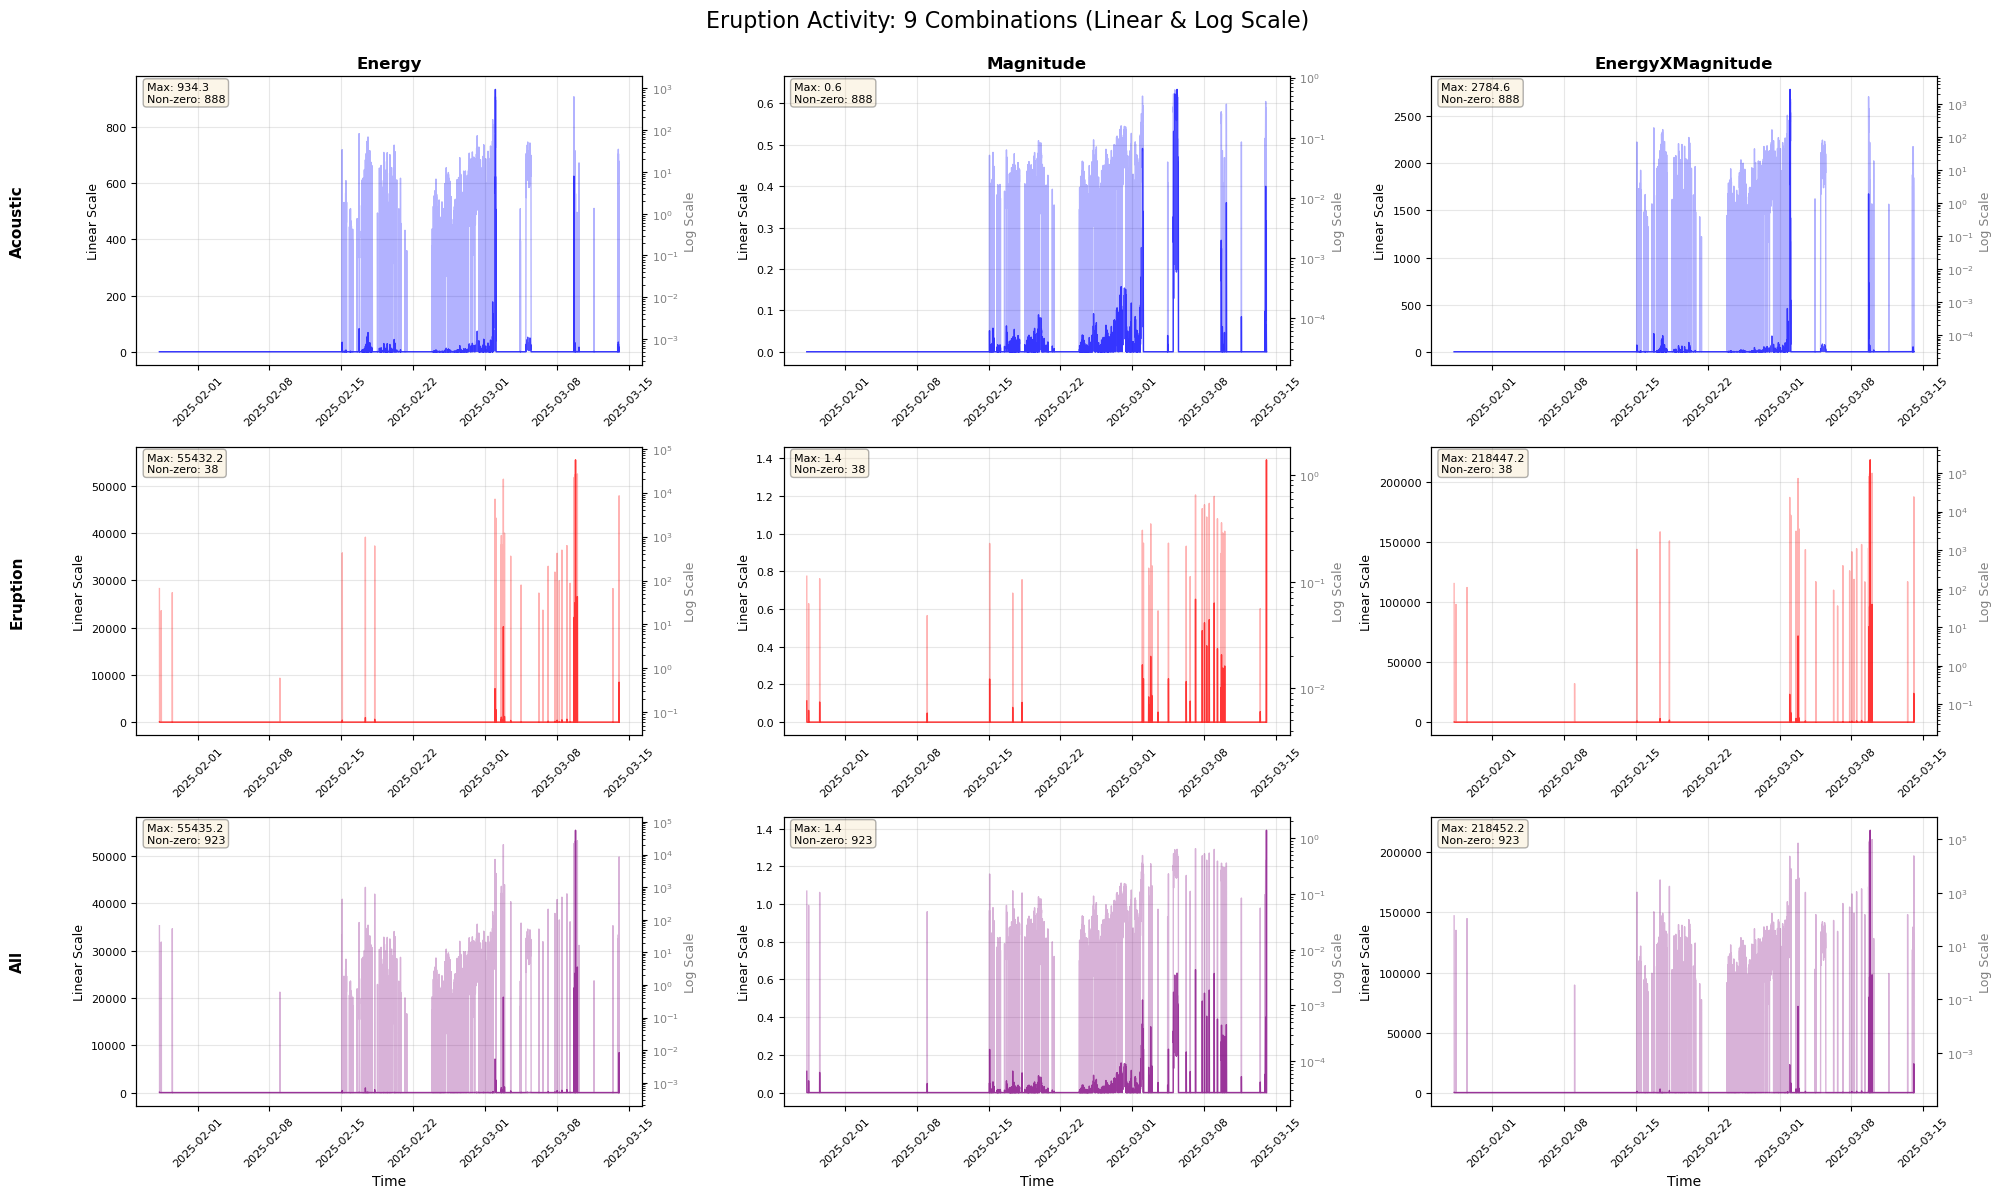

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import numpy as np

# --- Configuration ---
ACOUSTIC_FILE_NAME = 'Poas_discrete_2025-01-22_2025-03-15.csv'
TARGET_FILE_NAME = 'dataInterpolated.csv'
OUTPUT_CSV_NAME = 'eruption_activity.csv'

# 1. Load the acoustic data
df_acoustic = pd.read_csv(ACOUSTIC_FILE_NAME)
df_acoustic['t1'] = pd.to_datetime(df_acoustic['t1'])
df_acoustic['t2'] = pd.to_datetime(df_acoustic['t2'])

# 2. Setup the target time series grid
if os.path.exists(TARGET_FILE_NAME):
    print(f"File '{TARGET_FILE_NAME}' found. Using its time index.")
    df_target = pd.read_csv(TARGET_FILE_NAME, index_col=0, parse_dates=True)
    # NOTE: index_col=0 assumes the first column is the time index.
    # If your time column has a different name, change to: index_col='your_column_name'
    inferred_freq = pd.infer_freq(df_target.index)
    resample_rule = inferred_freq if inferred_freq else '10min'
    print(f"Inferred frequency: {resample_rule}")
else:
    print(f"File '{TARGET_FILE_NAME}' not found. Generating a synthetic time grid for testing.")
    resample_rule = '10min'
    start_time = df_acoustic['t1'].min().floor(resample_rule)
    end_time = df_acoustic['t2'].max().ceil(resample_rule)
    target_index = pd.date_range(start=start_time, end=end_time, freq=resample_rule)
    df_target = pd.DataFrame(index=target_index)

# 3. Classify data into 3 groups
acoustic_only = df_acoustic[df_acoustic['label'] == 'Acoustic']
eruption_only = df_acoustic[df_acoustic['label'] == 'Eruption']
all_events = df_acoustic  # Acoustic + Eruption

print(f"\nData summary:")
print(f"  Acoustic events: {len(acoustic_only)}")
print(f"  Eruption events: {len(eruption_only)}")
print(f"  Total events: {len(all_events)}")

# 4. Function to calculate activity with duration consideration
def calculate_activity(data, metric, resample_rule, target_index):
    """
    Calculate activity level for specified data and metric, considering event duration
    """
    if len(data) == 0:
        return pd.Series(0.0, index=target_index)
    
    result = pd.Series(0.0, index=target_index)
    bin_duration_seconds = pd.Timedelta(resample_rule).total_seconds()
    
    for _, event in data.iterrows():
        t1 = event['t1']
        t2 = event['t2']
        
        if metric == 'energy':
            value = event['energy']
        elif metric == 'magnitude':
            value = event['magnitude']
        elif metric == 'energy_x_magnitude':
            value = event['energy'] * event['magnitude']
        
        affected_bins = target_index[(target_index <= t2) & (target_index + pd.Timedelta(resample_rule) >= t1)]
        
        for bin_start in affected_bins:
            bin_end = bin_start + pd.Timedelta(resample_rule)
            overlap_start = max(t1, bin_start)
            overlap_end = min(t2, bin_end)
            overlap_seconds = (overlap_end - overlap_start).total_seconds()
            
            if overlap_seconds > 0:
                fraction = overlap_seconds / bin_duration_seconds
                result[bin_start] += value * fraction
    
    return result

# Dataset and metric definitions
datasets = {'Acoustic': acoustic_only, 'Eruption': eruption_only, 'All': all_events}

metrics = {'Energy': 'energy', 'Magnitude': 'magnitude', 'EnergyXMagnitude': 'energy_x_magnitude'}

# 5. Calculate all 9 combinations and store in DataFrame
df_output = pd.DataFrame(index=df_target.index)
df_output.index.name = 'time'

print("\nCalculating 9 combinations...")
for dataset_name, dataset in datasets.items():
    for metric_name, metric_type in metrics.items():
        column_name = f"{dataset_name}_{metric_name}"
        print(f"  {column_name}...")
        df_output[column_name] = calculate_activity(dataset, metric_type, resample_rule, df_target.index)

# 6. Add log columns for each metric
print("Adding log columns...")
for col in list(df_output.columns):
    log_col_name = f"{col}_Log"
    values = df_output[col]
    # Replace 0 with NaN for log (log(0) is undefined)
    log_values = values.replace(0, np.nan).apply(np.log10)
    df_output[log_col_name] = log_values

# 7. Save to CSV
df_output.to_csv(OUTPUT_CSV_NAME)
print(f"\nCSV saved: {OUTPUT_CSV_NAME}")
print(f"  Rows: {len(df_output)}")
print(f"  Columns ({len(df_output.columns)}): {list(df_output.columns)}")

# 8. Create 9 subplots (dual y-axis)
fig, axes = plt.subplots(3, 3, figsize=(20, 12))
fig.suptitle('Eruption Activity: 9 Combinations (Linear & Log Scale)', fontsize=16, y=0.995)

for i, (dataset_name, dataset) in enumerate(datasets.items()):
    for j, (metric_name, metric_type) in enumerate(metrics.items()):
        ax1 = axes[i, j]
        column_name = f"{dataset_name}_{metric_name}"
        activity = df_output[column_name]
        
        color = 'red' if dataset_name == 'Eruption' else ('blue' if dataset_name == 'Acoustic' else 'purple')
        
        # Left y-axis: Linear scale
        ax1.plot(df_output.index, activity, color=color, linewidth=1.0, alpha=0.7)
        ax1.set_ylabel('Linear Scale', fontsize=9, color='black')
        ax1.tick_params(axis='y', labelcolor='black', labelsize=8)
        ax1.grid(True, alpha=0.3)
        
        # Right y-axis: Log scale
        ax2 = ax1.twinx()
        activity_log = activity.copy()
        activity_log[activity_log == 0] = activity[activity > 0].min() * 0.1 if (activity > 0).any() else 0.001
        ax2.plot(df_output.index, activity_log, color=color, linewidth=1.0, alpha=0.3)
        ax2.set_yscale('log')
        ax2.set_ylabel('Log Scale', fontsize=9, color='gray')
        ax2.tick_params(axis='y', labelcolor='gray', labelsize=8)
        
        if i == 0:
            ax1.set_title(metric_name, fontsize=12, fontweight='bold')
        if j == 0:
            ax1.text(-0.25, 0.5, dataset_name, transform=ax1.transAxes, fontsize=11, fontweight='bold', rotation=90, verticalalignment='center')
        
        non_zero = activity[activity > 0]
        if len(non_zero) > 0:
            stats_text = f'Max: {activity.max():.1f}\nNon-zero: {len(non_zero)}'
        else:
            stats_text = 'All zeros'
        ax1.text(0.02, 0.98, stats_text, transform=ax1.transAxes, fontsize=8, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))
        
        if i == 2:
            ax1.set_xlabel('Time', fontsize=10)
        
        ax1.tick_params(axis='x', rotation=45, labelsize=8)

plt.tight_layout()
plt.show()